In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 

In [2]:
FILE_NAME = "/Users/karthikkannapiran/Downloads/Dataset_for_Data_Analytics.xlsx"
 
df = pd.read_excel(FILE_NAME)
df['Date'] = pd.to_datetime(df['Date'])
 
print("=" * 60)
print("STEP 1: DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

STEP 1: DATASET OVERVIEW
Shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

First 5 rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27  

In [3]:
print("\n" + "=" * 60)
print("STEP 2: BASIC STATISTICS")
print("=" * 60)
print(df.describe())
 
print("\nProduct counts:\n", df['Product'].value_counts())
print("\nOrder status counts:\n", df['OrderStatus'].value_counts())
print("\nPayment method counts:\n", df['PaymentMethod'].value_counts())
print("\nReferral source counts:\n", df['ReferralSource'].value_counts())


STEP 2: BASIC STATISTICS
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558

Product counts:
 Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

Order status counts:
 OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Del

In [4]:
# ------------------------------------------------------------------
# STEP 3 — Patterns with groupby
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3: PATTERNS (GROUPBY)")
print("=" * 60)
 
revenue_by_product = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print("\nRevenue by product:\n", revenue_by_product)
 
avg_order_value = df.groupby('Product')['TotalPrice'].mean().round(2).sort_values(ascending=False)
print("\nAverage order value by product:\n", avg_order_value)
 
status_crosstab = pd.crosstab(df['Product'], df['OrderStatus'])
print("\nProduct vs Order Status cross-tab:\n", status_crosstab)
 


STEP 3: PATTERNS (GROUPBY)

Revenue by product:
 Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

Average order value by product:
 Product
Laptop     1110.56
Chair      1098.99
Printer    1080.73
Monitor    1077.62
Tablet     1042.28
Desk        985.06
Phone       972.58
Name: TotalPrice, dtype: float64

Product vs Order Status cross-tab:
 OrderStatus  Cancelled  Delivered  Pending  Returned  Shipped
Product                                                      
Chair               45         33       41        28       31
Desk                35         32       38        32       33
Laptop              35         40       30        39       29
Monitor             35         31       29        36       32
Phone               31         38       28        31       28
Printer             35         29       37        38       42
Tablet              3

In [5]:
# ------------------------------------------------------------------
# STEP 4 — Trends over time
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 4: TRENDS OVER TIME")
print("=" * 60)
 
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_trend = df.groupby('YearMonth')['TotalPrice'].agg(['sum', 'count', 'mean']).round(2)
print("\nMonthly revenue trend:\n", monthly_trend)
 
yearly_trend = df.groupby(df['Date'].dt.year)['TotalPrice'].sum()
print("\nYearly revenue trend:\n", yearly_trend)


STEP 4: TRENDS OVER TIME

Monthly revenue trend:
                 sum  count     mean
YearMonth                          
2023-01    56685.75     47  1206.08
2023-02    40117.66     37  1084.26
2023-03    48609.37     43  1130.45
2023-04    27751.71     31   895.22
2023-05    63836.84     49  1302.79
2023-06    49500.19     45  1100.00
2023-07    42820.66     44   973.20
2023-08    54352.14     51  1065.73
2023-09    29526.67     29  1018.16
2023-10    52607.85     47  1119.32
2023-11    43079.67     41  1050.72
2023-12    43754.73     46   951.19
2024-01    38528.08     32  1204.00
2024-02    36909.57     32  1153.42
2024-03    36030.90     36  1000.86
2024-04    49613.14     50   992.26
2024-05    27909.11     34   820.86
2024-06    68068.54     53  1284.31
2024-07    42963.98     43   999.16
2024-08    31991.07     28  1142.54
2024-09    39794.98     44   904.43
2024-10    37226.97     31  1200.87
2024-11    32413.76     35   926.11
2024-12    38785.77     41   945.99
2025-01    29

In [6]:
# ------------------------------------------------------------------
# STEP 5 — Outlier detection (IQR method)
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 5: OUTLIER DETECTION")
print("=" * 60)
 
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f}  |  Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']]
      .sort_values('TotalPrice', ascending=False))
 


STEP 5: OUTLIER DETECTION
Lower bound: -1341.41  |  Upper bound: 3330.41
Number of outliers: 8
        OrderID  Product  Quantity  UnitPrice  TotalPrice
789   ORD200789   Tablet         5     691.28     3456.40
1122  ORD201122  Monitor         5     678.19     3390.95
632   ORD200632   Laptop         5     678.16     3390.80
469   ORD200469    Chair         5     676.98     3384.90
328   ORD200328   Tablet         5     674.04     3370.20
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
1065  ORD201065  Printer         5     666.80     3334.00


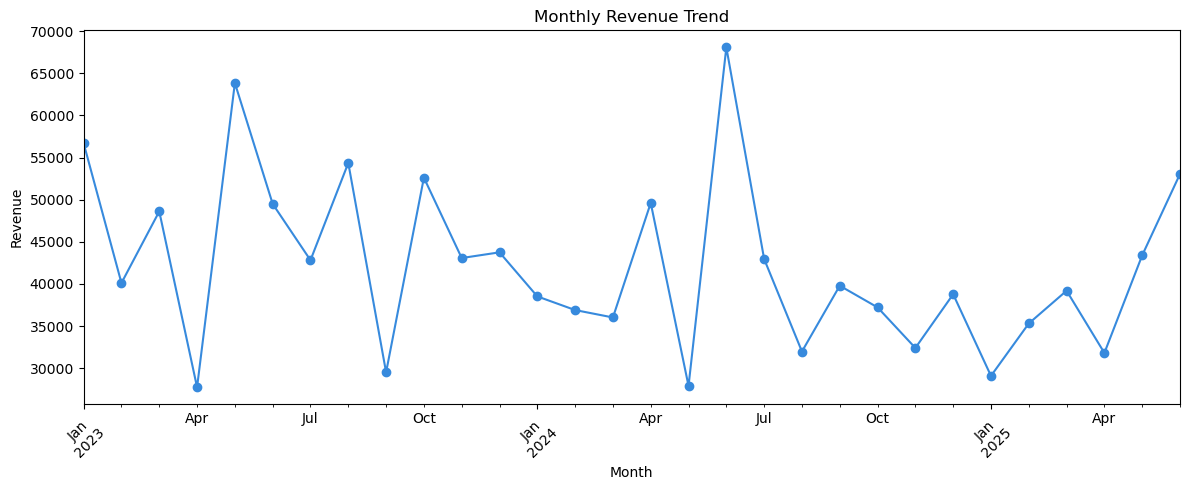

In [7]:
# ------------------------------------------------------------------
# STEP 6 — Visualisation: Monthly revenue trend (line chart)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 5))
monthly_trend['sum'].plot(kind='line', marker='o', color='#378ADD')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_1_monthly_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()
 

/var/folders/mc/gp6sx2h94wj_074glsy8b_jr0000gn/T/ipykernel_43632/3081249246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_product.values, y=revenue_by_product.index, palette='viridis')


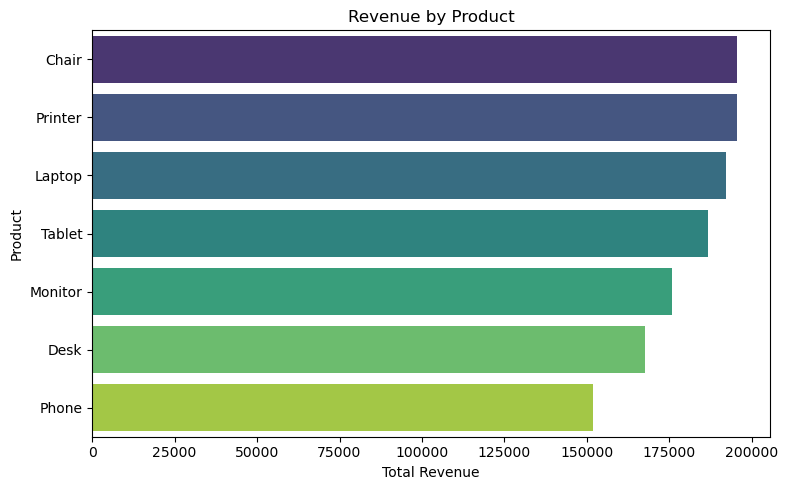

In [8]:
# ------------------------------------------------------------------
# STEP 7 — Visualisation: Revenue by product (bar chart)
# ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_product.values, y=revenue_by_product.index, palette='viridis')
plt.title('Revenue by Product')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('chart_2_revenue_by_product.png', dpi=300, bbox_inches='tight')
plt.show()

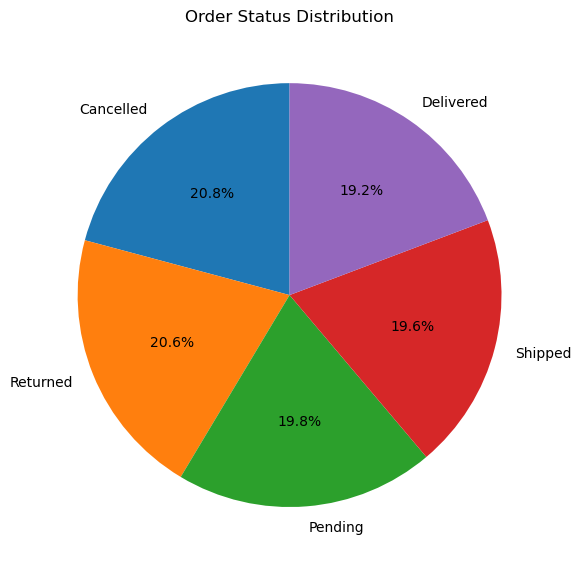

In [9]:
# ------------------------------------------------------------------
# STEP 8 — Visualisation: Order status distribution (pie chart)
# ------------------------------------------------------------------
status_counts = df['OrderStatus'].value_counts()
 
plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Order Status Distribution')
plt.tight_layout()
plt.savefig('chart_3_order_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

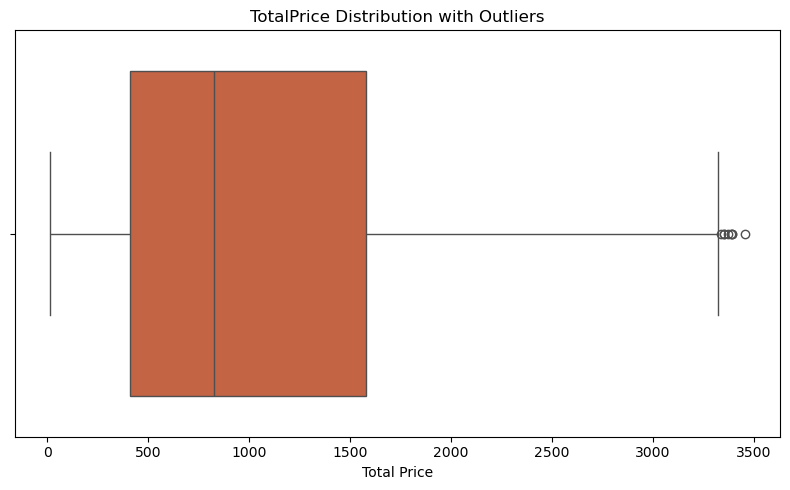

In [10]:
# ------------------------------------------------------------------
# STEP 9 — Visualisation: Outlier detection (boxplot)
# ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['TotalPrice'], color='#D85A30')
plt.title('TotalPrice Distribution with Outliers')
plt.xlabel('Total Price')
plt.tight_layout()
plt.savefig('chart_4_outlier_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


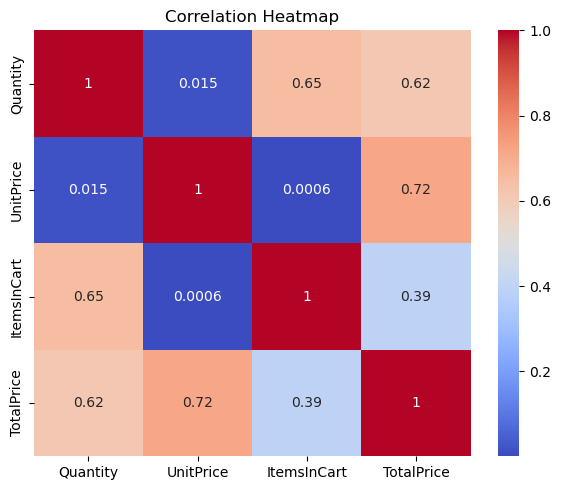

In [11]:
# ------------------------------------------------------------------
# STEP 10 — Visualisation: Correlation heatmap
# ------------------------------------------------------------------
numeric_cols = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]
 
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart_5_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# ------------------------------------------------------------------
# STEP 11 — Summary printout
# ------------------------------------------------------------------
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print("5 chart PNG files have been saved in the current folder:")
print("  1. chart_1_monthly_revenue_trend.png")
print("  2. chart_2_revenue_by_product.png")
print("  3. chart_3_order_status_distribution.png")
print("  4. chart_4_outlier_boxplot.png")
print("  5. chart_5_correlation_heatmap.png")
 


ANALYSIS COMPLETE
5 chart PNG files have been saved in the current folder:
  1. chart_1_monthly_revenue_trend.png
  2. chart_2_revenue_by_product.png
  3. chart_3_order_status_distribution.png
  4. chart_4_outlier_boxplot.png
  5. chart_5_correlation_heatmap.png
